
<div align="center">
  <hr>
  <h1><strong>🏢 Detección de Ocupación con Neurona General</strong></h1>

  <hr>
</div>


El repositorio para aprendizaje de redes neuronales está disponible de forma  pública en https://github.com/RNA-UNIV/rna

El objetivo del repositorio es el de proveer funciones y clases con implementaciones básicas de algoritmos de redes neuronales, carga de datasets, carga de modelos y carga de ejemplos para pruebas y visualizciones.

Se instala directamente desde el repositorio mediante **!pip install https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip**. Esta instalación descarga los archivos python para trabajar y prepara las estructuras de carpetas para realizar descargas de recursos (datasets, modelos, archivos, etc.) bajo demanda.

Para forzar la re-descarga e instalación de la última versión del repositorio, agregue la opción `--force-reinstall`:
**!pip install https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip --force-reinstall**
  
## 🎯 Objetivo
Este notebook demuestra el uso del repositorio `rna` para:

- 📚 **Cargar dataset**
- 📊 **Visualizar información** en formato JSON, árbol y tablas
- 🧠 **Implementar una neurona general con descenso de gradiente** para predecir la ocupación de una oficina (dataset occupancy detection)

## 📚 Contenido
- 🗃️ Instalación del Paquete
- 📥 Carga de dataset
- 🔍 Exploración de información
- 📊 Uso con NumPy y Pandas
- 🤖 Ejemplo con neurona general

## 🗃️ Instalación del Paquete

In [1]:
!pip install https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip
# Para forzar la re-descarga e instalación:
# !pip install https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip --force-reinstall


     \ 600.5 kB 9.6 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rna: filename=rna-0.1.0-py3-none-any.whl size=38171 sha256=d3df0253b6b628cc60a8c28b4e834240b2da83fb1b5986858308daa8f8525250
  Stored in directory: /tmp/pip-ephem-wheel-cache-0rwq5gp6/wheels/5b/35/5e/4cc5eea4d305f92826f6c97026e30cae40c203c3213a59d7f8
Successfully built rna


# 📥 Carga de Dataset con DataLoader

La clase `DataLoader` permite administrar datasets, modelos y recursos descargados automáticamente.

## 🔧 Funciones principales
1. 🔍 Consultar información.
2. 📊 Cargar como NumPy.
3. 🐼 Cargar como DataFrame.

En el repositorio Git de datasets, cada conjunto de datos cuenta con su propia carpeta, nombrada según el dataset. En su interior se encuentran el archivo de datos (en formato .csv o .zip), un documento Markdown con la documentación detallada y un archivo de metadatos (info.json). Estos archivos se descargan localmente bajo demanda, organizándose en una subcarpeta con el mismo nombre del dataset.

# 🚀 Ejemplos de Uso

> 💡 **Recomendación**
>
> Ejecute las celdas secuencialmente para comprender el flujo completo de trabajo.

## 🔍 Información del Dataset **Detección de Ocupación**
`dataset_info` retorna la información en formato **json** mientras que `dataset_info_display` muestra la información en formato mas legible, ej: arbol

In [3]:
from rna.data import DataLoader

DataLoader.dataset_info_display('occupancy_detection')

<IPython.core.display.JSON object>

In [4]:
# Usar método dataset_info para recuperar json con la información
DataLoader.dataset_info_display('occupancy_detection')

<IPython.core.display.JSON object>

## 🏢 Carga del dataset **Detección de Ocupación** como arreglo NumPy

In [ ]:
from pandas import DataFrame
from IPython.display import display
(cols, data) = DataLoader.load_array('occupancy_detection')

# convierte a DataFrame para mejor visualización
df = DataFrame(data, columns=cols)
display(df)

## 🏢 Carga de dataset **Detección de Ocupación** como DataFrame Pandas

In [5]:
df = DataLoader.load_dataframe('occupancy_detection')

display(df.head(5))

  [1/2] occupancy_detection.csv  ✓ (0.3s)
  [2/2] occupancy_detection.md  ✓ (0.1s)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-11 14:48:00,21.7600,31.133333,437.333333,1029.666667,0.005021,1
2,2015-02-11 14:49:00,21.7900,31.000000,437.333333,1000.000000,0.005009,1
3,2015-02-11 14:50:00,21.7675,31.122500,434.000000,1003.750000,0.005022,1
4,2015-02-11 14:51:00,21.7675,31.122500,439.000000,1009.500000,0.005022,1
5,2015-02-11 14:51:59,21.7900,31.133333,437.333333,1005.666667,0.005030,1


# 👨‍👩‍👧‍👦 Detección de Ocupación

Ejemplo completo de entrenamiento y evaluación de Neurona General.

In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from rna.ClassNeuronaGral import NeuronaGradiente

df = DataLoader.load_dataframe('occupancy_detection')

feature_columns = ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio']
x_data_raw = df[feature_columns]

y_data = df['Occupancy'].to_numpy()
class_names = ['Vacío', 'Ocupado']

# Drop rows where any of the numerical features are NaN (due to coercion)
x_data = x_data_raw.dropna().to_numpy()

# Escalar características
data_scaler = StandardScaler()
X_scaled = data_scaler.fit_transform(x_data)

print("🔄 Entrenando modelo...")
modelo = NeuronaGradiente(epochs=200, alpha=0.001, FUN='sigmoid', COSTO='EC_binaria', verbose=1)
modelo.fit(X_scaled, y_data);

🔄 Entrenando modelo...
Época 200/200 - 100.0% |██████████████████████████████| ec_binaria: 0.295682

# 📈 Evaluación y Resultados

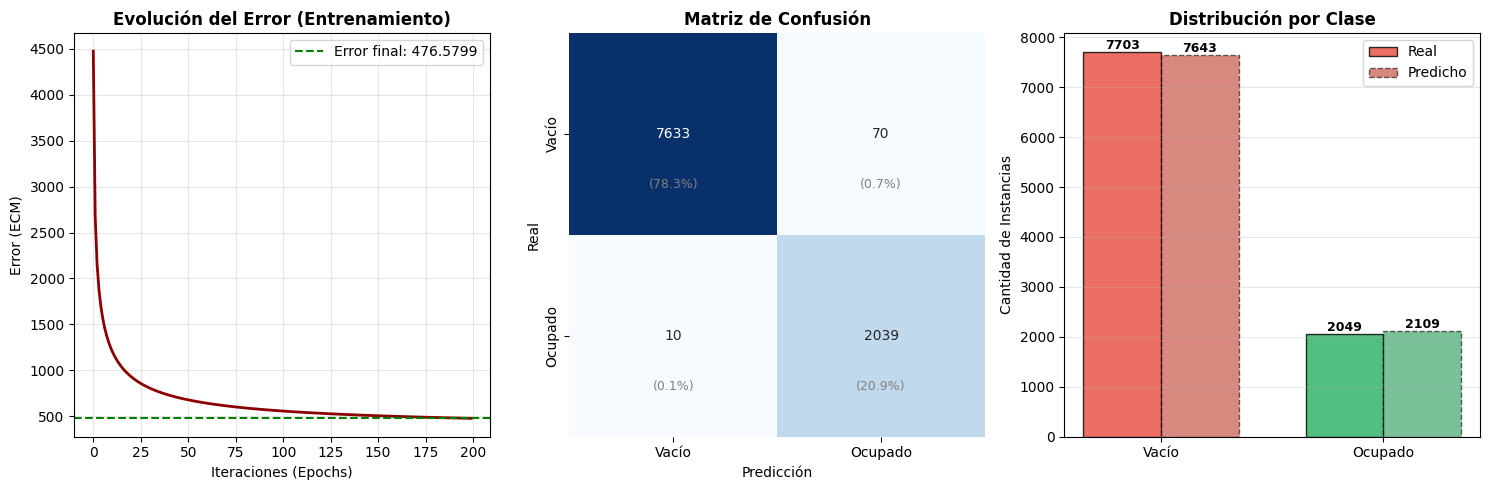


📊 ESTADÍSTICAS DEL ENTRENAMIENTO:
  • Error inicial: 4474.246739
  • Error final..: 476.579868
  • Mejora.......: 89.3%

🎯 MÉTRICAS DE CLASIFICACIÓN BINARIA:
  • Accuracy  (Precisión global).....: 0.9918 (99.18%)
  • Precision (Calidad predicción)...: 0.9668
  • Recall    (Sensibilidad).........: 0.9951
  • F1-Score  (Balance P-R)..........: 0.9808

🧮 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
  • Verdaderos Negativos  (correctamente libres)..................: 7633
  • Falsos Positivos      (predichos como ocupados pero NO lo son): 70
  • Falsos Negativos      (predichos como libres pero SÍ lo son)..: 10
  • Verdaderos Positivos  (correctamente ocupados)................: 2039

📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

       Vacío       1.00      0.99      0.99      7703
     Ocupado       0.97      1.00      0.98      2049

    accuracy                           0.99      9752
   macro avg       0.98      0.99      0.99      9752
weighted avg       0

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

y_pred_raw = modelo.predict(X_scaled)
y_pred = y_pred_raw  # Ya viene como 0 o 1 desde predict()
y_true = y_data


# Definir las clases y sus nombres para los gráficos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Gráfico 1: Evolución del Error ---
ax1 = axes[0]
if hasattr(modelo, 'errors_') and len(modelo.errors_) > 0:
    ax1.plot(modelo.errors_, color='darkred', linewidth=2)
    ax1.set_title('Evolución del Error (Entrenamiento)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Iteraciones (Epochs)', fontsize=10)
    ax1.set_ylabel('Error (ECM)', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=modelo.errors_[-1], color='green', linestyle='--',
                label=f'Error final: {modelo.errors_[-1]:.4f}')
    ax1.legend()

# --- Gráfico 2: Matriz de Confusión ---
ax2 = axes[1]
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax2, cbar=False)
ax2.set_title('Matriz de Confusión', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicción', fontsize=10)
ax2.set_ylabel('Real', fontsize=10)

# Agregar porcentajes
total = len(y_true)
for i in range(2):
    for j in range(2):
        pct = (cm[i, j] / total) * 100
        ax2.text(j + 0.5, i + 0.75, f'({pct:.1f}%)', ha='center', va='center', fontsize=9, color='gray')

# --- Gráfico 3: Distribución Real vs Predicho ---
ax3 = axes[2]
real_counts = [np.sum(y_true == 0), np.sum(y_true == 1)]
pred_counts = [np.sum(y_pred == 0), np.sum(y_pred == 1)]
x_pos = np.arange(2)
width = 0.35

bars1 = ax3.bar(x_pos - width/2, real_counts, width, label='Real',
                color=['#e74c3c', '#27ae60'], alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, pred_counts, width, label='Predicho',
                color=['#c0392b', '#229954'], alpha=0.6, edgecolor='black', linestyle='--')

# Agregar números sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 5, f'{int(height)}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_title('Distribución por Clase', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(class_names)
ax3.set_ylabel('Cantidad de Instancias', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend()

plt.tight_layout()
plt.show()


# Métricas Varias
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n📊 ESTADÍSTICAS DEL ENTRENAMIENTO:")
if hasattr(modelo, 'errors_') and len(modelo.errors_) > 0:
    print(f"  • Error inicial: {modelo.errors_[0]:.6f}")
    print(f"  • Error final..: {modelo.errors_[-1]:.6f}")
    print(f"  • Mejora.......: {((modelo.errors_[0] - modelo.errors_[-1]) / modelo.errors_[0])*100:.1f}%")

print("\n🎯 MÉTRICAS DE CLASIFICACIÓN BINARIA:")
print(f"  • Accuracy  (Precisión global).....: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  • Precision (Calidad predicción)...: {precision:.4f}")
print(f"  • Recall    (Sensibilidad).........: {recall:.4f}")
print(f"  • F1-Score  (Balance P-R)..........: {f1:.4f}")

print("\n🧮 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")
print(f"  • Verdaderos Negativos  (correctamente libres)..................: {cm[0,0]}")
print(f"  • Falsos Positivos      (predichos como ocupados pero NO lo son): {cm[0,1]}")
print(f"  • Falsos Negativos      (predichos como libres pero SÍ lo son)..: {cm[1,0]}")
print(f"  • Verdaderos Positivos  (correctamente ocupados)................: {cm[1,1]}")

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print("\n💡 INTERPRETACIÓN:")
print(f"  → El modelo acierta el {accuracy*100:.1f}% de las predicciones.")
if precision > 0:
    print(f"  → De todos los que predijo como 'Ocupado', el {precision*100:.1f}% realmente lo estaba.")
if recall > 0:
    print(f"  → De todos los que realmente estaban 'Ocupados', el modelo detectó al {recall*100:.1f}%.")